In [86]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tifffile import imread, imwrite, TiffFile
from cellpose import models
from skimage.measure import regionprops, regionprops_table, label
from skimage.morphology import skeletonize
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from imageio.v2 import imread as imageio_imread

User settings

In [41]:
raw_data_dir = "../data/final_test/raw_data"
brightfield_dir = "../data/final_test/brightfield_frames"
gfp_dir = "../data/final_test/gfp_frames"
filament_dir = "../data/final_test/filament_mask"
cell_mask_dir = "../data/final_test/cellpose_mask"
output_dir = "../data/final_test/results"

# Set to True once to split raw 2-channel time stacks into per-frame TIFFs
split_raw_stacks = True

# Channel order in raw stacks after reading:
# channel 0 = brightfield, channel 1 = GFP
brightfield_channel_index = 0
gfp_channel_index = 1

model_type_bf = "cyto3"
model_type_gfp = "cyto3"
diameter_bf = None
diameter_gfp = None
channels_bf = [0, 0]
channels_gfp = [0, 0]
use_gpu = False

# Keep BF objects only if they overlap the first GFP reference enough
pillar_iou_threshold = 0.10

# Optional tiny-object cleanup
min_area_bf = 50
min_area_gfp = 20

# Reuse saved cell masks if they already exist
use_existing_cell_masks = False

# Tracking settings
max_link_distance = 60
min_overlap_fraction = 0.15
bud_distance = 35
bud_overlap_fraction = 0.05

Preprocessing: split raw 2-channel time stacks into single-frame TIFFs

In [42]:
import os
import numpy as np
from tifffile import imread, imwrite

input_dir = "../data/final_test/raw_data"
brightfield_dir = "../data/final_test/brightfield_frames"
gfp_dir = "../data/final_test/gfp_frames"

os.makedirs(brightfield_dir, exist_ok=True)
os.makedirs(gfp_dir, exist_ok=True)


def split_stack(img):
    print("Original shape:", img.shape)

    # Case 1: already (T, C, Y, X)
    if img.ndim == 4 and img.shape[1] == 2:
        pass

    # Case 2: (T, Y, X, C)
    elif img.ndim == 4 and img.shape[-1] == 2:
        img = np.transpose(img, (0, 3, 1, 2))

    # Case 3: flattened (T*2, Y, X)
    elif img.ndim == 3:
        z, y, x = img.shape
        if z % 2 != 0:
            raise ValueError(f"Expected even number of slices, got {z}")
        t = z // 2
        img = img.reshape(t, 2, y, x)

    else:
        raise ValueError(f"Unsupported shape {img.shape}")

    print("Converted to:", img.shape, "(T, C, Y, X)")
    return img


files = [f for f in os.listdir(input_dir) if f.lower().endswith((".tif", ".tiff"))]

if not files:
    raise RuntimeError(f"No TIFF files found in {input_dir}")

for file in files:
    path = os.path.join(input_dir, file)
    stem = os.path.splitext(file)[0]

    print(f"\nProcessing {file}")
    img = imread(path)
    img = split_stack(img)

    T, C, Y, X = img.shape

    for t in range(T):
        bf = img[t, 0]
        gfp = img[t, 1]

        bf_out = os.path.join(brightfield_dir, f"{stem}_frame_{t+1:04d}_BF.tif")
        gfp_out = os.path.join(gfp_dir, f"{stem}_frame_{t+1:04d}_GFP.tif")

        imwrite(bf_out, bf)
        imwrite(gfp_out, gfp)

    print(f"Wrote {T} BF frames to {brightfield_dir}")
    print(f"Wrote {T} GFP frames to {gfp_dir}")

print("Done")


Processing ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped.tiff
Original shape: (50, 2, 128, 128)
Converted to: (50, 2, 128, 128) (T, C, Y, X)
Wrote 50 BF frames to ../data/final_test/brightfield_frames
Wrote 50 GFP frames to ../data/final_test/gfp_frames
Done


Helper functions for segmentation and measurements

In [43]:

def remove_small_objects_from_labelmask(mask, min_area):
    props = pd.DataFrame(regionprops_table(mask, properties=["label", "area"]))
    if len(props) == 0:
        return np.zeros_like(mask, dtype=np.int32)

    keep_labels = props.loc[props["area"] >= min_area, "label"].astype(int).tolist()
    clean_mask = np.zeros_like(mask, dtype=np.int32)
    for new_label, old_label in enumerate(keep_labels, start=1):
        clean_mask[mask == old_label] = new_label
    return clean_mask


def segment_frame_cellpose(img, model, diameter=None, channels=None):
    eval_kwargs = {
        "diameter": diameter,
        "normalize": True,
        "do_3D": False,
    }

    if channels is not None:
        eval_kwargs["channels"] = channels

    result = model.eval(img, **eval_kwargs)

    if isinstance(result, tuple):
        masks = result[0]
    else:
        masks = result

    return masks


def build_pillar_reference_mask(gfp_path, gfp_model):
    gfp_img = imread(gfp_path)
    gfp_masks = segment_frame_cellpose(
        gfp_img,
        model=gfp_model,
        diameter=diameter_gfp,
        channels=channels_gfp,
    )
    gfp_masks = remove_small_objects_from_labelmask(gfp_masks, min_area_gfp)
    return gfp_img, gfp_masks


def compute_iou(mask_a, label_a, mask_b, label_b):
    a = (mask_a == label_a)
    b = (mask_b == label_b)
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    if union == 0:
        return 0.0
    return inter / union


def filter_bf_mask_with_gfp_reference(bf_mask, gfp_reference_mask, iou_threshold=0.10):
    """
    Keep BF objects only if they overlap a GFP object enough,
    using best IoU against the GFP reference mask.
    """
    filtered_bf_masks = np.zeros_like(bf_mask, dtype=np.int32)
    kept_rows = []
    new_label = 1

    gfp_labels = [r.label for r in regionprops(gfp_reference_mask)]

    for bf_region in regionprops(bf_mask):
        bf_label = bf_region.label

        best_iou = 0.0
        best_gfp_label = None

        for gfp_label in gfp_labels:
            iou = compute_iou(bf_mask, bf_label, gfp_reference_mask, gfp_label)
            if iou > best_iou:
                best_iou = iou
                best_gfp_label = gfp_label

        keep = best_iou >= iou_threshold

        kept_rows.append({
            "bf_label": int(bf_label),
            "best_gfp_label": None if best_gfp_label is None else int(best_gfp_label),
            "best_iou": float(best_iou),
            "keep": bool(keep),
        })

        if keep:
            filtered_bf_masks[bf_mask == bf_label] = new_label
            new_label += 1

    debug_df = pd.DataFrame(kept_rows).sort_values("bf_label") if len(kept_rows) > 0 else pd.DataFrame()
    return filtered_bf_masks, debug_df

Tracking helper for cells

In [44]:
def track_cells_one_movie(movie_name, frames_data,
                          max_link_distance,
                          min_overlap_fraction,
                          bud_distance,
                          bud_overlap_fraction):
    next_cell_id = 1
    tracked_rows = []

    prev_df = None
    prev_mask = None

    for fd in frames_data:
        frame = fd["frame"]
        curr_df = fd["props"].copy()
        curr_mask = fd["mask"]

        if len(curr_df) == 0:
            prev_df = curr_df.copy()
            prev_mask = curr_mask.copy()
            continue

        curr_df["cell_ID"] = -1
        curr_df["mother_cell_ID"] = np.nan

        if prev_df is None or len(prev_df) == 0:
            for idx in curr_df.index:
                curr_df.loc[idx, "cell_ID"] = next_cell_id
                next_cell_id += 1

        else:
            prev_coords = prev_df[["centroid_y", "centroid_x"]].to_numpy()
            curr_coords = curr_df[["centroid_y", "centroid_x"]].to_numpy()

            dist_mat = cdist(prev_coords, curr_coords)
            cost_mat = dist_mat.copy()

            for i, prev_row in enumerate(prev_df.itertuples()):
                for j, curr_row in enumerate(curr_df.itertuples()):
                    overlap_frac = compute_overlap_fraction(
                        prev_mask, prev_row.label,
                        curr_mask, curr_row.label
                    )

                    if overlap_frac >= min_overlap_fraction:
                        cost_mat[i, j] *= 0.25
                    elif dist_mat[i, j] > max_link_distance:
                        cost_mat[i, j] = 1e6

            row_ind, col_ind = linear_sum_assignment(cost_mat)

            assigned_prev = set()
            assigned_curr = set()

            for i, j in zip(row_ind, col_ind):
                if cost_mat[i, j] >= 1e6:
                    continue

                prev_row = prev_df.iloc[i]
                curr_idx = curr_df.index[j]

                curr_df.loc[curr_idx, "cell_ID"] = int(prev_row["cell_ID"])
                assigned_prev.add(i)
                assigned_curr.add(j)

            unassigned_curr = [j for j in range(len(curr_df)) if j not in assigned_curr]

            for j in unassigned_curr:
                curr_idx = curr_df.index[j]
                curr_label = curr_df.loc[curr_idx, "label"]
                curr_y = curr_df.loc[curr_idx, "centroid_y"]
                curr_x = curr_df.loc[curr_idx, "centroid_x"]

                curr_df.loc[curr_idx, "cell_ID"] = next_cell_id
                next_cell_id += 1

                best_mother = None
                best_score = -1

                for i in range(len(prev_df)):
                    prev_row = prev_df.iloc[i]
                    prev_label = prev_row["label"]
                    prev_id = prev_row["cell_ID"]

                    d = np.sqrt(
                        (curr_y - prev_row["centroid_y"])**2 +
                        (curr_x - prev_row["centroid_x"])**2
                    )
                    overlap_frac = compute_overlap_fraction(
                        prev_mask, prev_label,
                        curr_mask, curr_label
                    )

                    score = 0
                    if d <= bud_distance:
                        score += (bud_distance - d) / bud_distance
                    if overlap_frac >= bud_overlap_fraction:
                        score += overlap_frac * 2

                    if score > best_score and score > 0:
                        best_score = score
                        best_mother = prev_id

                if best_mother is not None:
                    curr_df.loc[curr_idx, "mother_cell_ID"] = best_mother

        tracked_rows.append(curr_df)
        prev_df = curr_df.copy()
        prev_mask = curr_mask.copy()

    if len(tracked_rows) == 0:
        return pd.DataFrame()

    tracked_df = pd.concat(tracked_rows, ignore_index=True)
    tracked_df["movie"] = movie_name
    return tracked_df

helper for loading existing cellpose masks

In [45]:
def get_cell_mask_path(movie_name, frame):
    return os.path.join(cell_mask_dir, f"{movie_name}_frame_{frame}_cellmask.tif")


def load_existing_cell_mask(movie_name, frame):
    mask_path = get_cell_mask_path(movie_name, frame)
    if not os.path.exists(mask_path):
        raise FileNotFoundError(f"Missing existing cell mask: {mask_path}")
    return imread(mask_path)

In [46]:
def clean_cell_mask(mask, min_cell_area=0):
    mask = np.asarray(mask)

    if min_cell_area is None or min_cell_area <= 0:
        return mask.astype(np.int32)

    out = np.zeros_like(mask, dtype=np.int32)
    next_label = 1

    for label_id in np.unique(mask):
        if label_id == 0:
            continue

        obj = (mask == label_id)
        if obj.sum() >= min_cell_area:
            out[obj] = next_label
            next_label += 1

    return out

In [47]:
def get_cell_props(mask, frame, movie_name):
    mask = np.asarray(mask)

    props = regionprops_table(
        mask,
        properties=[
            "label",
            "area",
            "centroid",
            "bbox",
            "eccentricity",
            "solidity",
            "major_axis_length",
            "minor_axis_length",
        ],
    )

    df = pd.DataFrame(props)

    if df.empty:
        return pd.DataFrame(columns=[
            "movie_name",
            "frame",
            "label",
            "area",
            "centroid_y",
            "centroid_x",
            "bbox_min_row",
            "bbox_min_col",
            "bbox_max_row",
            "bbox_max_col",
            "eccentricity",
            "solidity",
            "major_axis_length",
            "minor_axis_length",
        ])

    df = df.rename(columns={
        "centroid-0": "centroid_y",
        "centroid-1": "centroid_x",
        "bbox-0": "bbox_min_row",
        "bbox-1": "bbox_min_col",
        "bbox-2": "bbox_max_row",
        "bbox-3": "bbox_max_col",
    })

    df.insert(0, "movie_name", movie_name)
    df.insert(1, "frame", frame)

    return df

In [57]:
def compute_overlap_fraction(prev_mask, curr_mask, prev_label, curr_label):
    prev_mask = np.asarray(prev_mask)
    curr_mask = np.asarray(curr_mask)

    prev_obj = (prev_mask == prev_label)
    curr_obj = (curr_mask == curr_label)

    prev_area = np.sum(prev_obj)
    curr_area = np.sum(curr_obj)

    if prev_area == 0 or curr_area == 0:
        return 0.0

    overlap = np.sum(prev_obj & curr_obj)

    return overlap / min(prev_area, curr_area)

In [58]:
def format_frame_token(frame):
    """
    Keep frame naming consistent across split frames, saved masks, and loaders.
    Output filenames use zero-padded 1-based frame tokens like 0001.
    """
    return f"{int(frame):04d}"


frame_file_pattern = re.compile(
    r"^(?P<movie>.+)_frame_(?P<frame>\d+)_(?P<channel>BF|GFP)\.tif{1,2}$",
    re.IGNORECASE
)


def collect_movie_frames(frame_dir, expected_channel):
    movies_dict = {}

    for path in sorted(glob.glob(os.path.join(frame_dir, "*.tif*"))):
        fname = os.path.basename(path)
        match = frame_file_pattern.match(fname)

        if match is None:
            print(f"Skipping unmatched file: {fname}")
            continue

        channel = match.group("channel").upper()
        if channel != expected_channel.upper():
            continue

        movie_name = match.group("movie")
        frame = int(match.group("frame"))

        movies_dict.setdefault(movie_name, []).append((frame, path))

    for movie_name in movies_dict:
        movies_dict[movie_name] = sorted(movies_dict[movie_name], key=lambda x: x[0])

    return movies_dict


movies = collect_movie_frames(brightfield_dir, expected_channel="BF")
gfp_movies = collect_movie_frames(gfp_dir, expected_channel="GFP")

print(f"Found {len(movies)} BF movies and {len(gfp_movies)} GFP movies")

for movie_name in sorted(movies):
    bf_count = len(movies[movie_name])
    gfp_count = len(gfp_movies.get(movie_name, []))
    print(f"  {movie_name}: BF={bf_count}, GFP={gfp_count}")

if not movies:
    raise RuntimeError(
        f"No brightfield frame files matched the expected pattern in {brightfield_dir}. "
        "Expected names like <movie>_frame_0001_BF.tif"
    )


Found 1 BF movies and 1 GFP movies
  ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped: BF=50, GFP=50


Without visuals - segmentation and cleanup

In [59]:
model_bf = None
model_gfp = None
if not use_existing_cell_masks:
    model_bf = models.CellposeModel(gpu=use_gpu)
    model_gfp = models.CellposeModel(gpu=use_gpu)

all_cell_tracks = []
movie_frames_store = {}

for movie_name, frame_list in movies.items():
    print(f"\nProcessing movie: {movie_name}")

    frames_data = []

    for frame, path in frame_list:
        img = imread(path)

        out_mask_path = get_cell_mask_path(movie_name, frame)

        # If mask already exists → load it
        if os.path.exists(out_mask_path):
            clean_mask = imread(out_mask_path)
            bf_masks = clean_mask.copy()
            filter_debug_df = pd.DataFrame()

        else:
            # Otherwise compute it
            if use_existing_cell_masks:
                clean_mask = load_existing_cell_mask(movie_name, frame)
                bf_masks = clean_mask.copy()
            else:
                bf_masks = segment_frame_cellpose(
                    img,
                    model=model_bf,
                    diameter=diameter_bf,
                    channels=channels_bf,
                )
                bf_masks = clean_cell_mask(bf_masks, min_cell_area=min_area_bf)
                clean_mask = bf_masks.copy()

            filter_debug_df = pd.DataFrame()

            # Save newly computed mask
            imwrite(out_mask_path, clean_mask.astype(np.uint16))

        if len(filter_debug_df) > 0:
            kept_count = int(filter_debug_df["keep"].sum())
            removed_count = int((~filter_debug_df["keep"]).sum())
            print(
                f"  frame {frame}: kept {kept_count} BF objects "
                f"with GFP overlap, removed {removed_count}"
            )

        cell_props = get_cell_props(clean_mask, frame, movie_name)

        frames_data.append({
            "frame": frame,
            "image": img,
            "mask": clean_mask,
            "props": cell_props,
        })

    movie_frames_store[movie_name] = frames_data

    tracked_df = track_cells_one_movie(
        movie_name,
        frames_data,
        max_link_distance=max_link_distance,
        min_overlap_fraction=min_overlap_fraction,
        bud_distance=bud_distance,
        bud_overlap_fraction=bud_overlap_fraction,
    )

    if tracked_df is not None and not tracked_df.empty:
        all_cell_tracks.append(tracked_df)
    else:
        print(f"Warning: no tracked cells produced for {movie_name}")

cell_tracks_df = (
    pd.concat(all_cell_tracks, ignore_index=True)
    if len(all_cell_tracks) > 0
    else pd.DataFrame()
)

if not cell_tracks_df.empty and "frame" in cell_tracks_df.columns:
    cell_tracks_df["frame_viewer"] = cell_tracks_df["frame"]
else:
    print("Warning: cell_tracks_df is empty or missing 'frame' column")

cell_tracks_df.to_csv(
    os.path.join(output_dir, "cell_tracks_per_frame.csv"),
    index=False
)

print("\nSaved:", os.path.join(output_dir, "cell_tracks_per_frame.csv"))
cell_tracks_df.head()


Processing movie: ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped

Saved: ../data/final_test/results/cell_tracks_per_frame.csv


,movie_name,frame,label,area,centroid_y,centroid_x,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,eccentricity,solidity,major_axis_length,minor_axis_length,cell_ID,mother_cell_ID,movie,frame_viewer
0,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,1,249.0,15.811245,43.024096,7,35,25,52,0.386475,0.961390,18.557153,17.115263,1,NaN,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1
1,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,2,529.0,38.470699,43.809074,26,31,52,57,0.274736,0.968864,26.497547,25.477917,2,NaN,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1
2,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,3,708.0,55.413842,68.238701,40,53,73,84,0.437169,0.965894,31.844295,28.640096,3,NaN,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1
3,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,4,456.0,65.850877,44.607456,53,32,80,58,0.824564,0.968153,32.089985,18.155499,4,NaN,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1
4,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,5,476.0,65.838235,92.733193,53,80,80,106,0.794515,0.977413,31.658266,19.224325,5,NaN,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1


Filament measurement helpers

In [79]:
def skeleton_length_px(binary_mask):
    skel = skeletonize(binary_mask > 0)
    return float(skel.sum())


def get_filament_props(filament_mask, frame, movie_name):
    lab = label(filament_mask > 0)

    rows = []
    labels_present = [x for x in np.unique(lab) if x != 0]

    for i, region_label in enumerate(labels_present, start=1):
        reg = (lab == region_label)

        props = regionprops_table(
            reg.astype(np.uint8),
            properties=[
                "label", "area", "centroid", "bbox",
                "eccentricity", "solidity",
                "major_axis_length", "minor_axis_length"
            ]
        )

        df = pd.DataFrame(props)
        if len(df) == 0:
            continue

        df["movie"] = movie_name
        df["frame"] = frame
        df["mean_length_px"] = skeleton_length_px(reg)
        df["filament_local_label"] = i

        df = df.rename(columns={
            "centroid-0": "centroid_y",
            "centroid-1": "centroid_x",
            "bbox-0": "bbox_min_row",
            "bbox-1": "bbox_min_col",
            "bbox-2": "bbox_max_row",
            "bbox-3": "bbox_max_col",
        })

        rows.append(df)

    if len(rows) == 0:
        return pd.DataFrame(columns=[
            "movie", "frame", "label", "area", "centroid_y", "centroid_x",
            "bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col",
            "eccentricity", "solidity", "major_axis_length", "minor_axis_length",
            "mean_length_px", "filament_local_label"
        ])

    return pd.concat(rows, ignore_index=True)

Assigning filament detections to tracked cells

In [76]:
def assign_filaments_to_cells(filament_mask, cell_mask, filament_props_df, tracked_cells_frame_df):
    """
    Assign each filament object to the tracked cell_ID whose cell mask
    contains the largest number of filament pixels.

    Parameters
    ----------
    filament_mask : 2D array
        Binary or labeled filament mask for one frame.
    cell_mask : 2D array
        Labeled cell mask for the same frame.
    filament_props_df : pandas.DataFrame
        Output from get_filament_props() for this frame.
    tracked_cells_frame_df : pandas.DataFrame
        Subset of cell_tracks_df for this movie + frame.

    Returns
    -------
    pandas.DataFrame
        filament_props_df plus:
        - cell_ID
        - overlap_pixels_with_cell
    """
    if len(filament_props_df) == 0:
        empty_df = filament_props_df.copy()
        empty_df["cell_ID"] = pd.Series(dtype="float")
        empty_df["overlap_pixels_with_cell"] = pd.Series(dtype="int")
        return empty_df

    out_rows = []
    lab = label(filament_mask > 0)

    for _, row in filament_props_df.iterrows():
        filament_label = int(row["filament_local_label"])
        reg = (lab == filament_label)

        overlapped_cells = cell_mask[reg]
        overlapped_cells = overlapped_cells[overlapped_cells > 0]

        assigned_cell_id = np.nan
        overlap_pixels = 0

        if len(overlapped_cells) > 0:
            vals, counts = np.unique(overlapped_cells, return_counts=True)
            best_cell_label = vals[np.argmax(counts)]
            overlap_pixels = int(counts.max())

            matched = tracked_cells_frame_df.loc[
                tracked_cells_frame_df["label"] == best_cell_label
            ]

            if len(matched) > 0:
                assigned_cell_id = matched.iloc[0]["cell_ID"]

        row2 = row.copy()
        row2["cell_ID"] = assigned_cell_id
        row2["overlap_pixels_with_cell"] = overlap_pixels
        out_rows.append(row2)

    return pd.DataFrame(out_rows)

Helper to find filament mask files

In [81]:
def get_filament_mask_path(movie_name, frame, filament_dir):
    """
    Match filenames like:
    {movie_name}_mask_{frame_index}_1.png

    where:
    - image frames are 1-based
    - filament masks are 0-based
    """
    mask_frame = int(frame) - 1
    base = f"{movie_name}_mask_{mask_frame}_1"

    for ext in ["", ".png", ".tif", ".tiff"]:
        path = os.path.join(filament_dir, base + ext)
        if os.path.exists(path):
            return path

    return None

Load filament masks and build per-frame filament table

In [88]:
all_filaments = []

for movie_name, frames_data in movie_frames_store.items():
    print(f"Loading filaments for {movie_name}")

    for fd in frames_data:
        frame = fd["frame"]
        cell_mask = fd["mask"]

        filament_path = get_filament_mask_path(
            movie_name=movie_name,
            frame=frame,
            filament_dir=filament_dir
        )

        # No mask file = no filament in this frame
        if filament_path is None:
            continue

        filament_mask = imageio_imread(filament_path)

        if filament_mask.ndim == 3:
            filament_mask = filament_mask[..., 0]

        filament_mask = (filament_mask > 0).astype(np.uint8)

        filament_props = get_filament_props(
            filament_mask=filament_mask,
            frame=frame,
            movie_name=movie_name
        )

        tracked_cells_frame_df = cell_tracks_df[
            (cell_tracks_df["movie"] == movie_name) &
            (cell_tracks_df["frame"] == frame)
        ].copy()

        assigned_df = assign_filaments_to_cells(
            filament_mask=filament_mask,
            cell_mask=cell_mask,
            filament_props_df=filament_props,
            tracked_cells_frame_df=tracked_cells_frame_df
        )

        if len(assigned_df) > 0:
            all_filaments.append(assigned_df)

# combine all filament detections
if len(all_filaments) > 0:
    filaments_per_frame_df = pd.concat(all_filaments, ignore_index=True)
else:
    filaments_per_frame_df = pd.DataFrame(columns=[
        "movie", "frame", "cell_ID", "label", "area", "centroid_y", "centroid_x",
        "bbox_min_row", "bbox_min_col", "bbox_max_row", "bbox_max_col",
        "eccentricity", "solidity", "major_axis_length", "minor_axis_length",
        "mean_length_px", "filament_local_label", "overlap_pixels_with_cell"
    ])

# because there should be only one filament per cell per frame,
# keep one row per movie/frame/cell_ID
if len(filaments_per_frame_df) > 0:
    filaments_per_frame_df = (
        filaments_per_frame_df
        .sort_values(["movie", "frame", "cell_ID", "area"], ascending=[True, True, True, False])
        .drop_duplicates(subset=["movie", "frame", "cell_ID"], keep="first")
        .copy()
    )

# rename filament columns so they don't clash with cell columns
filament_merge_df = filaments_per_frame_df.rename(columns={
    "label": "filament_label",
    "area": "filament_area",
    "centroid_y": "filament_centroid_y",
    "centroid_x": "filament_centroid_x",
    "bbox_min_row": "filament_bbox_min_row",
    "bbox_min_col": "filament_bbox_min_col",
    "bbox_max_row": "filament_bbox_max_row",
    "bbox_max_col": "filament_bbox_max_col",
    "eccentricity": "filament_eccentricity",
    "solidity": "filament_solidity",
    "major_axis_length": "filament_major_axis_length",
    "minor_axis_length": "filament_minor_axis_length",
    "mean_length_px": "filament_mean_length_px",
})

# optional presence flag
if len(filament_merge_df) > 0:
    filament_merge_df["filament_present"] = 1

# choose only useful filament columns for merging
filament_merge_df = filament_merge_df[[
    "movie", "frame", "cell_ID",
    "filament_present",
    "filament_local_label",
    "filament_label",
    "filament_area",
    "filament_centroid_y",
    "filament_centroid_x",
    "filament_bbox_min_row",
    "filament_bbox_min_col",
    "filament_bbox_max_row",
    "filament_bbox_max_col",
    "filament_eccentricity",
    "filament_solidity",
    "filament_major_axis_length",
    "filament_minor_axis_length",
    "filament_mean_length_px",
    "overlap_pixels_with_cell"
]] if len(filament_merge_df) > 0 else pd.DataFrame(columns=[
    "movie", "frame", "cell_ID",
    "filament_present",
    "filament_local_label",
    "filament_label",
    "filament_area",
    "filament_centroid_y",
    "filament_centroid_x",
    "filament_bbox_min_row",
    "filament_bbox_min_col",
    "filament_bbox_max_row",
    "filament_bbox_max_col",
    "filament_eccentricity",
    "filament_solidity",
    "filament_major_axis_length",
    "filament_minor_axis_length",
    "filament_mean_length_px",
    "overlap_pixels_with_cell"
])

# merge onto the cell table
cell_tracks_with_filaments_df = cell_tracks_df.merge(
    filament_merge_df,
    on=["movie", "frame", "cell_ID"],
    how="left"
)

# fill missing filament presence with 0
if "filament_present" in cell_tracks_with_filaments_df.columns:
    cell_tracks_with_filaments_df["filament_present"] = (
        cell_tracks_with_filaments_df["filament_present"]
        .fillna(0)
        .astype(int)
    )

filaments_per_frame_df["frame_viewer"] = (
    filaments_per_frame_df["frame"] + 1
)

# save both versions
filaments_per_frame_df.to_csv(
    os.path.join(output_dir, "filaments_per_frame.csv"),
    index=False
)

cell_tracks_with_filaments_df["frame_viewer"] = (
    cell_tracks_with_filaments_df["frame"] + 1
)

cell_tracks_with_filaments_df.to_csv(
    os.path.join(output_dir, "cell_tracks_per_frame_with_filaments.csv"),
    index=False
)

print("Saved:", os.path.join(output_dir, "filaments_per_frame.csv"))
print("Saved:", os.path.join(output_dir, "cell_tracks_per_frame_with_filaments.csv"))

cell_tracks_with_filaments_df.head()

Loading filaments for ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped
Saved: ../data/final_test/results/filaments_per_frame.csv
Saved: ../data/final_test/results/cell_tracks_per_frame_with_filaments.csv


,movie_name,frame,label,area,centroid_y,centroid_x,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,filament_bbox_min_row,filament_bbox_min_col,filament_bbox_max_row,filament_bbox_max_col,filament_eccentricity,filament_solidity,filament_major_axis_length,filament_minor_axis_length,filament_mean_length_px,overlap_pixels_with_cell
0,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,1,249.0,15.811245,43.024096,7,35,25,52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,2,529.0,38.470699,43.809074,26,31,52,57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,3,708.0,55.413842,68.238701,40,53,73,84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,4,456.0,65.850877,44.607456,53,32,80,58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,5,476.0,65.838235,92.733193,53,80,80,106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Building filament episodes from the merged table

In [89]:
def build_filament_episodes(cell_tracks_with_filaments_df, max_gap):
    """
    Build continuous filament episodes from the merged per-cell-per-frame table.

    Assumes at most one filament per cell per frame.

    Parameters
    ----------
    cell_tracks_with_filaments_df : pandas.DataFrame
        Per-cell-per-frame table with filament columns merged in.
    max_gap : int
        Number of missing frames allowed within one filament episode.

    Returns
    -------
    per_frame_with_ids_df : pandas.DataFrame
        Rows where filament is present, with filament_ID added.
    episodes_df : pandas.DataFrame
        One row per filament episode.
    """
    df = cell_tracks_with_filaments_df.copy()

    if "filament_present" not in df.columns:
        return pd.DataFrame(), pd.DataFrame()

    df = df[df["filament_present"] == 1].copy()

    if len(df) == 0:
        return pd.DataFrame(), pd.DataFrame()

    df["cell_ID"] = df["cell_ID"].astype(int)
    df = df.sort_values(["movie", "cell_ID", "frame"]).reset_index(drop=True)

    per_frame_rows = []
    episode_rows = []
    next_filament_id = 1

    for (movie, cell_id), grp in df.groupby(["movie", "cell_ID"]):
        grp = grp.sort_values("frame").reset_index(drop=True)

        current_episode_id = None
        prev_frame = None

        episode_frames = []
        episode_lengths = []
        episode_areas = []

        for _, row in grp.iterrows():
            frame = int(row["frame"])

            new_episode = False
            if prev_frame is None:
                new_episode = True
            elif (frame - prev_frame) > (max_gap + 1):
                new_episode = True

            if new_episode:
                if current_episode_id is not None:
                    episode_rows.append({
                        "movie": movie,
                        "cell_ID": cell_id,
                        "filament_ID": current_episode_id,
                        "time_of_appearance": min(episode_frames),
                        "last_seen_frame": max(episode_frames),
                        "duration_frames": len(episode_frames),
                        "filament_count": 1,
                        "mean_length_px": float(np.mean(episode_lengths)),
                        "mean_area_px": float(np.mean(episode_areas)),
                    })

                current_episode_id = next_filament_id
                next_filament_id += 1
                episode_frames = []
                episode_lengths = []
                episode_areas = []

            episode_frames.append(frame)
            episode_lengths.append(row["filament_mean_length_px"])
            episode_areas.append(row["filament_area"])

            row2 = row.copy()
            row2["filament_ID"] = current_episode_id
            row2["time_of_appearance"] = min(episode_frames)
            per_frame_rows.append(row2)

            prev_frame = frame

        if current_episode_id is not None and len(episode_frames) > 0:
            episode_rows.append({
                "movie": movie,
                "cell_ID": cell_id,
                "filament_ID": current_episode_id,
                "time_of_appearance": min(episode_frames),
                "last_seen_frame": max(episode_frames),
                "duration_frames": len(episode_frames),
                "filament_count": 1,
                "mean_length_px": float(np.mean(episode_lengths)),
                "mean_area_px": float(np.mean(episode_areas)),
            })

    per_frame_with_ids_df = pd.DataFrame(per_frame_rows)
    episodes_df = pd.DataFrame(episode_rows)

    return per_frame_with_ids_df, episodes_df

Run filament episode building and save outputs

In [90]:
max_filament_gap = 1  # or 2 or 3 depending on how tolerant you want to be

filaments_with_ids_df, filament_episodes_df = build_filament_episodes(
    cell_tracks_with_filaments_df=cell_tracks_with_filaments_df,
    max_gap=max_filament_gap
)

filaments_with_ids_df.to_csv(
    os.path.join(output_dir, "filaments_with_IDs_per_frame.csv"),
    index=False
)

filament_episodes_df.to_csv(
    os.path.join(output_dir, "filament_episodes.csv"),
    index=False
)

print("Saved:", os.path.join(output_dir, "filaments_with_IDs_per_frame.csv"))
print("Saved:", os.path.join(output_dir, "filament_episodes.csv"))

filament_episodes_df.head()

Saved: ../data/final_test/results/filaments_with_IDs_per_frame.csv
Saved: ../data/final_test/results/filament_episodes.csv


,movie,cell_ID,filament_ID,time_of_appearance,last_seen_frame,duration_frames,filament_count,mean_length_px,mean_area_px
0,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,1,6,20,13,1,3.230769,12.923077
1,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,2,23,24,2,1,3.000000,11.500000
2,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,3,28,31,4,1,3.000000,8.000000
3,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,4,34,34,1,1,2.000000,9.000000


Add lineage info to filament episodes

In [91]:
cell_lineage_df = (
    cell_tracks_df[["movie", "cell_ID", "mother_cell_ID"]]
    .drop_duplicates()
    .sort_values(["movie", "cell_ID"])
    .reset_index(drop=True)
)

filament_episodes_with_lineage_df = filament_episodes_df.merge(
    cell_lineage_df,
    on=["movie", "cell_ID"],
    how="left"
)

filament_episodes_with_lineage_df["time_of_appearance_viewer"] = (
    filament_episodes_with_lineage_df["time_of_appearance"] 
)

filament_episodes_with_lineage_df["last_seen_frame_viewer"] = (
    filament_episodes_with_lineage_df["last_seen_frame"] 
)

filament_episodes_with_lineage_df.to_csv(
    os.path.join(output_dir, "filament_episodes_with_lineage.csv"),
    index=False
)

print("Saved:", os.path.join(output_dir, "filament_episodes_with_lineage.csv"))
filament_episodes_with_lineage_df.head()

Saved: ../data/final_test/results/filament_episodes_with_lineage.csv


,movie,cell_ID,filament_ID,time_of_appearance,last_seen_frame,duration_frames,filament_count,mean_length_px,mean_area_px,mother_cell_ID,time_of_appearance_viewer,last_seen_frame_viewer
0,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,1,6,20,13,1,3.230769,12.923077,NaN,6,20
1,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,2,23,24,2,1,3.000000,11.500000,NaN,23,24
2,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,3,28,31,4,1,3.000000,8.000000,NaN,28,31
3,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,4,34,34,1,1,2.000000,9.000000,NaN,34,34


Make a per-cell summary table

In [92]:
if len(filament_episodes_df) > 0:
    filament_count_per_cell = (
        filament_episodes_df.groupby(["movie", "cell_ID"])["filament_ID"]
        .nunique()
        .reset_index(name="filament_count")
    )

    first_filament_time_per_cell = (
        filament_episodes_df.groupby(["movie", "cell_ID"])["time_of_appearance"]
        .min()
        .reset_index(name="first_time_of_appearance")
    )

    mean_filament_length_per_cell = (
        filament_episodes_df.groupby(["movie", "cell_ID"])["mean_length_px"]
        .mean()
        .reset_index(name="mean_filament_length_px")
    )

    mean_filament_area_per_cell = (
        filament_episodes_df.groupby(["movie", "cell_ID"])["mean_area_px"]
        .mean()
        .reset_index(name="mean_filament_area_px")
    )

    total_filament_duration_per_cell = (
        filament_episodes_df.groupby(["movie", "cell_ID"])["duration_frames"]
        .sum()
        .reset_index(name="total_filament_duration_frames")
    )

    cell_filament_summary_df = filament_count_per_cell.merge(
        first_filament_time_per_cell,
        on=["movie", "cell_ID"],
        how="outer"
    )

    cell_filament_summary_df = cell_filament_summary_df.merge(
        mean_filament_length_per_cell,
        on=["movie", "cell_ID"],
        how="left"
    )

    cell_filament_summary_df = cell_filament_summary_df.merge(
        mean_filament_area_per_cell,
        on=["movie", "cell_ID"],
        how="left"
    )

    cell_filament_summary_df = cell_filament_summary_df.merge(
        total_filament_duration_per_cell,
        on=["movie", "cell_ID"],
        how="left"
    )

    cell_filament_summary_df = cell_filament_summary_df.merge(
        cell_lineage_df,
        on=["movie", "cell_ID"],
        how="left"
    )

else:
    cell_filament_summary_df = cell_lineage_df.copy()
    cell_filament_summary_df["filament_count"] = 0
    cell_filament_summary_df["first_time_of_appearance"] = np.nan
    cell_filament_summary_df["mean_filament_length_px"] = np.nan
    cell_filament_summary_df["mean_filament_area_px"] = np.nan
    cell_filament_summary_df["total_filament_duration_frames"] = 0

cell_filament_summary_df.to_csv(
    os.path.join(output_dir, "cell_filament_summary.csv"),
    index=False
)

print("Saved:", os.path.join(output_dir, "cell_filament_summary.csv"))
cell_filament_summary_df.head()

Saved: ../data/final_test/results/cell_filament_summary.csv


,movie,cell_ID,filament_count,first_time_of_appearance,mean_filament_length_px,mean_filament_area_px,total_filament_duration_frames,mother_cell_ID
0,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,3,4,6,2.807692,10.355769,20,NaN


Add filament episode info back onto the per-frame cell table

In [93]:
if len(filaments_with_ids_df) > 0:
    filament_id_merge_df = filaments_with_ids_df[[
        "movie", "frame", "cell_ID", "filament_ID", "time_of_appearance"
    ]].drop_duplicates()

    cell_tracks_with_filaments_and_ids_df = cell_tracks_with_filaments_df.merge(
        filament_id_merge_df,
        on=["movie", "frame", "cell_ID"],
        how="left"
    )
else:
    cell_tracks_with_filaments_and_ids_df = cell_tracks_with_filaments_df.copy()
    cell_tracks_with_filaments_and_ids_df["filament_ID"] = np.nan
    cell_tracks_with_filaments_and_ids_df["time_of_appearance"] = np.nan

cell_tracks_with_filaments_and_ids_df["frame_viewer"] = (
    cell_tracks_with_filaments_and_ids_df["frame"] 
)

cell_tracks_with_filaments_and_ids_df.to_csv(
    os.path.join(output_dir, "cell_tracks_per_frame_with_filaments_and_ids.csv"),
    index=False
)

print("Saved:", os.path.join(output_dir, "cell_tracks_per_frame_with_filaments_and_ids.csv"))
cell_tracks_with_filaments_and_ids_df.head()

Saved: ../data/final_test/results/cell_tracks_per_frame_with_filaments_and_ids.csv


,movie_name,frame,label,area,centroid_y,centroid_x,bbox_min_row,bbox_min_col,bbox_max_row,bbox_max_col,...,filament_bbox_max_row,filament_bbox_max_col,filament_eccentricity,filament_solidity,filament_major_axis_length,filament_minor_axis_length,filament_mean_length_px,overlap_pixels_with_cell,filament_ID,time_of_appearance
0,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,1,249.0,15.811245,43.024096,7,35,25,52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,2,529.0,38.470699,43.809074,26,31,52,57,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,3,708.0,55.413842,68.238701,40,53,73,84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,4,456.0,65.850877,44.607456,53,32,80,58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ch20_URA7_URA8_001_Brightfield_GFP_z01_cropped,1,5,476.0,65.838235,92.733193,53,80,80,106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Quick checks

In [94]:
print("Number of tracked cell-frame rows:", len(cell_tracks_df))
print("Number of cell-frame rows with merged filament info:", len(cell_tracks_with_filaments_df))
print("Number of filament-positive rows:", int(cell_tracks_with_filaments_df["filament_present"].sum()) if "filament_present" in cell_tracks_with_filaments_df.columns else 0)
print("Number of filament episodes:", len(filament_episodes_df))
print("Number of cells with at least one filament:", cell_filament_summary_df["filament_count"].gt(0).sum() if "filament_count" in cell_filament_summary_df.columns else 0)

Number of tracked cell-frame rows: 300
Number of cell-frame rows with merged filament info: 300
Number of filament-positive rows: 20
Number of filament episodes: 4
Number of cells with at least one filament: 1


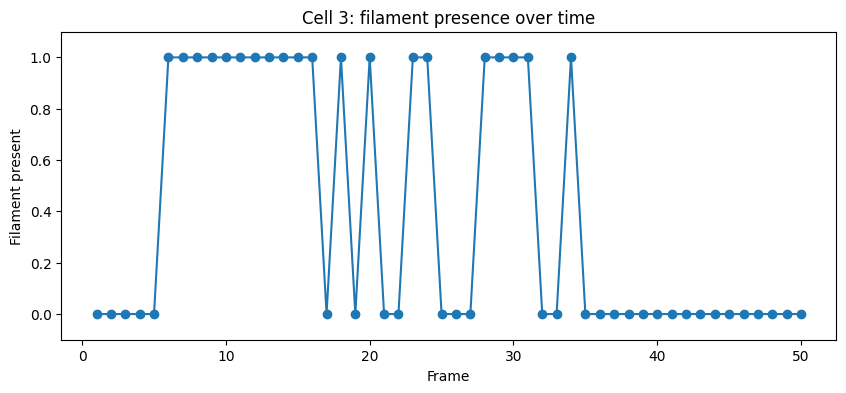

In [99]:
example_df = cell_tracks_with_filaments_and_ids_df.copy()

example_cells = example_df.loc[
    example_df["filament_present"] == 1, "cell_ID"
].dropna().unique()

if len(example_cells) > 0:
    example_cell_id = example_cells[0]

    plot_df = example_df[example_df["cell_ID"] == example_cell_id].sort_values("frame")

    plt.figure(figsize=(10, 4))
    plt.plot(plot_df["frame"], plot_df["filament_present"], marker="o")
    plt.xlabel("Frame")
    plt.ylabel("Filament present")
    plt.title(f"Cell {example_cell_id}: filament presence over time")
    plt.ylim(-0.1, 1.1)
    plt.show()
else:
    print("No cells with filament detections found.")

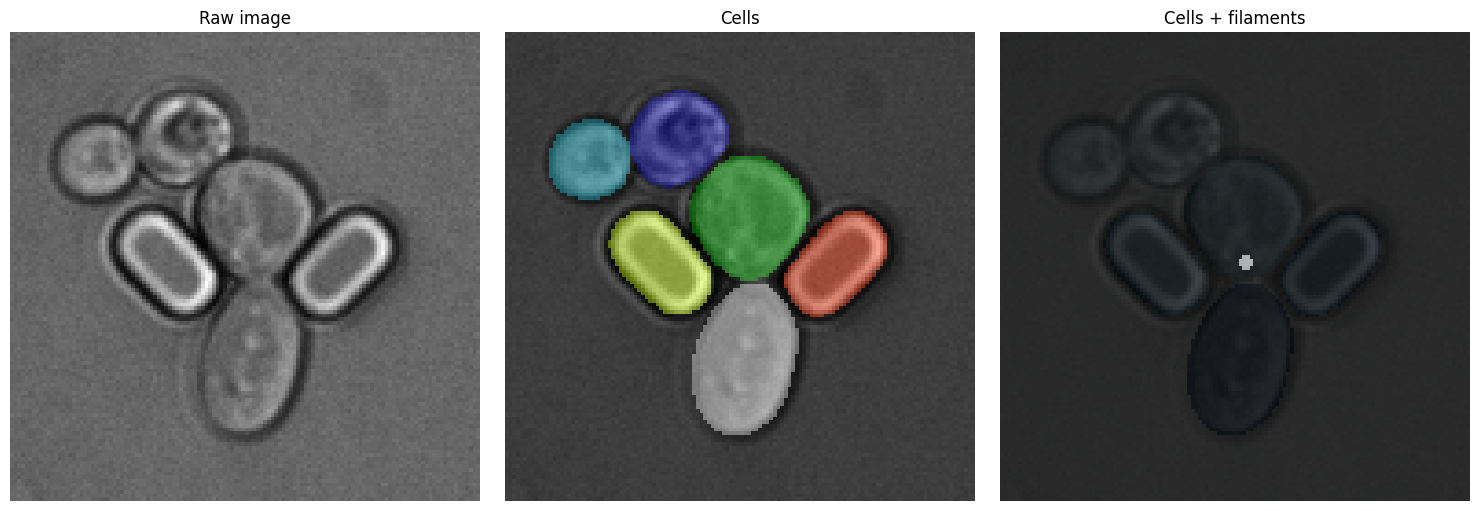

In [105]:
movie_name = list(movie_frames_store.keys())[0]
frame_idx = 22

fd = movie_frames_store[movie_name][frame_idx]
img = fd["image"]
cell_mask = fd["mask"]
frame = fd["frame"]

filament_path = get_filament_mask_path(
    movie_name=movie_name,
    frame=frame,
    filament_dir=filament_dir
)

if filament_path is not None:
    filament_mask = imageio_imread(filament_path)

    if filament_mask.ndim == 3:
        filament_mask = filament_mask[..., 0]

    filament_mask = (filament_mask > 0).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Raw image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(img, cmap="gray")
    plt.imshow(cell_mask, cmap="nipy_spectral", alpha=0.4)
    plt.title("Cells")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(cell_mask, cmap="Blues", alpha=0.25)
    plt.imshow(filament_mask > 0, cmap="nipy_spectral", alpha=0.7)
    plt.title("Cells + filaments")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"No filament mask found for {movie_name} frame {frame}")

Helper to lead a full mask timelapse

In [106]:
def build_mask_stack_from_files(frame_list, get_mask_path_func, dtype=np.uint16):
    """
    Build a time stack of masks for one movie.
    
    Parameters
    ----------
    frame_list : list of tuples
        [(frame_number, raw_image_path), ...]
    get_mask_path_func : function
        Function taking frame_number and returning path or None
    dtype : numpy dtype
        Output dtype for stack
        
    Returns
    -------
    stack : np.ndarray
        Shape (n_frames, height, width)
    frames_sorted : list
        Frame numbers in order
    """
    if len(frame_list) == 0:
        return None, []

    frames_sorted = [frame for frame, _ in frame_list]

    # use first raw image to get shape
    first_img = imread(frame_list[0][1])
    height, width = first_img.shape[:2]

    stack = np.zeros((len(frames_sorted), height, width), dtype=dtype)

    for i, (frame, _) in enumerate(frame_list):
        mask_path = get_mask_path_func(frame)

        if mask_path is None:
            continue

        mask = imread(mask_path)

        if mask.shape != (height, width):
            raise ValueError(
                f"Mask shape mismatch at frame {frame}: "
                f"expected {(height, width)}, got {mask.shape}"
            )

        stack[i] = mask.astype(dtype)

    return stack, frames_sorted